## 0. Setup

In [1]:
import time
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             roc_auc_score,
                             average_precision_score,
                             PrecisionRecallDisplay,
                             RocCurveDisplay)

import matplotlib.pyplot as plt

In [2]:
start_time = time.time()

## 1. Data Loading

### 1.1. Validating Dataset Path

In [3]:
DATA_PATH = Path("../Kaggle_Industrial_IoT_Dataset/factory_sensor_simulator_2040.csv")

# validate dataset path
def validate_csv_path(path, label):
    if not path.exists():
        raise FileNotFoundError(f">> [ERROR] {label} not found at: {path.resolve()}\n"
                                f">> [INFO] Download from: https://www.kaggle.com/datasets/canozensoy/industrial-iot-dataset-synthetic/data")
    if not path.is_file():
        raise ValueError(f">> [ERROR] {label} exists but is not a file: {path.resolve()}")
    if path.suffix.lower() != ".csv":
        raise ValueError(f">> [ERROR] {label} is not a CSV file: {path.resolve()}")
    
    print(f">> [OK] {label}: {path.resolve()}")
    
validate_csv_path(DATA_PATH, "Industrial IoT Dataset (Synthetic)")

>> [OK] Industrial IoT Dataset (Synthetic): C:\Users\david\Desktop\Year 1 Sem 2\ICT5101 - IoT_Project\PartB\Kaggle_Industrial_IoT_Dataset\factory_sensor_simulator_2040.csv


### 1.2. Loading Dataset

In [4]:
df = pd.read_csv(DATA_PATH)

display(df.head(10))
print(f">> [INFO] Shape: {df.shape}")
print("\n>> --- [Data Types] --- :")
print(df.dtypes)

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0
5,MC_000005,Labeler,2001,69956,53.58,14.31,54.79,39.97,85.49,105.33,...,1,False,0,163.0,False,NaN,NaN,NaN,NaN,0
6,MC_000006,Automated_Screwdriver,2025,2578,62.44,8.42,97.15,80.57,19.88,207.15,...,2,False,1,908.0,False,NaN,NaN,NaN,NaN,0
7,MC_000007,Automated_Screwdriver,2005,39895,27.28,16.09,38.66,87.98,38.66,122.53,...,0,False,6,467.0,False,NaN,NaN,NaN,NaN,0
8,MC_000008,Shrink_Wrapper,2020,19992,69.31,9.69,82.15,62.04,41.63,145.71,...,3,True,4,794.0,False,NaN,NaN,NaN,NaN,0
9,MC_000009,Shrink_Wrapper,2029,13151,69.18,13.10,84.82,38.36,73.15,178.91,...,1,False,6,925.0,False,NaN,NaN,NaN,NaN,0


>> [INFO] Shape: (500000, 22)

>> --- [Data Types] --- :
Machine_ID                        str
Machine_Type                      str
Installation_Year               int64
Operational_Hours               int64
Temperature_C                 float64
Vibration_mms                 float64
Sound_dB                      float64
Oil_Level_pct                 float64
Coolant_Level_pct             float64
Power_Consumption_kW          float64
Last_Maintenance_Days_Ago       int64
Maintenance_History_Count       int64
Failure_History_Count           int64
AI_Supervision                   bool
Error_Codes_Last_30_Days        int64
Remaining_Useful_Life_days    float64
Failure_Within_7_Days            bool
Laser_Intensity               float64
Hydraulic_Pressure_bar        float64
Coolant_Flow_L_min            float64
Heat_Index                    float64
AI_Override_Events              int64
dtype: object


## 2. Data Cleaning

### 2.1. Drop **Machine_ID** and **Remaining_Useful_Life_days**

- Machine_ID is just an identifier with no useful information. If kept, model can memorise machine IDs

- `Remaining_Useful_Life_days` is probably very closely related to the target `Failure_Within_7_Days`
    - Ex. If Remaining_Useful_Life_days <= 7, then Failure_Within_7_Days is likely True.

    - Model might get unrealistically good results (padded results)

In [5]:
df = df.drop(columns=["Machine_ID"])                    # Drop identifier
df = df.drop(columns=["Remaining_Useful_Life_days"])    # Avoid data leakage

display(df.head(5))

,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,5,True,3,False,NaN,NaN,NaN,NaN,2
1,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,2,True,4,False,NaN,NaN,40.92,NaN,2
2,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,1,True,6,True,NaN,NaN,NaN,NaN,2
3,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,1,False,4,False,NaN,NaN,NaN,NaN,0
4,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,2,False,1,False,NaN,NaN,NaN,NaN,0


### 2.2. Converting **Booleans** to **Integers**

In [6]:
df["AI_Supervision"] = df["AI_Supervision"].astype(int)
df["Failure_Within_7_Days"] = df["Failure_Within_7_Days"].astype(int)

display(df.head(5))
print("\n>> --- [Data Types] --- :")
print(df.dtypes)

,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,5,1,3,0,NaN,NaN,NaN,NaN,2
1,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,2,1,4,0,NaN,NaN,40.92,NaN,2
2,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,1,1,6,1,NaN,NaN,NaN,NaN,2
3,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,1,0,4,0,NaN,NaN,NaN,NaN,0
4,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,2,0,1,0,NaN,NaN,NaN,NaN,0



>> --- [Data Types] --- :
Machine_Type                     str
Installation_Year              int64
Operational_Hours              int64
Temperature_C                float64
Vibration_mms                float64
Sound_dB                     float64
Oil_Level_pct                float64
Coolant_Level_pct            float64
Power_Consumption_kW         float64
Last_Maintenance_Days_Ago      int64
Maintenance_History_Count      int64
Failure_History_Count          int64
AI_Supervision                 int64
Error_Codes_Last_30_Days       int64
Failure_Within_7_Days          int64
Laser_Intensity              float64
Hydraulic_Pressure_bar       float64
Coolant_Flow_L_min           float64
Heat_Index                   float64
AI_Override_Events             int64
dtype: object


### 2.3. Handling Null Values

In [7]:
def null_summary(df):
    nulls_df = (
        pd.DataFrame({
            "Column": df.columns,
            "Has NULL": df.isnull().any().values,
            "Number": df.isnull().sum().values
        })
        .sort_values(by="Number", ascending=False)
        .reset_index(drop=True)
    )

    has_nulls = nulls_df[nulls_df["Has NULL"] == True]

    if has_nulls.empty:
        print(f">> [INFO] No NULL values found.")
        return
        
    display(has_nulls)

    return has_nulls["Column"].tolist()

In [8]:
cols_with_nulls = null_summary(df)

,Column,Has NULL,Number
0,Laser_Intensity,True,484844
1,Hydraulic_Pressure_bar,True,469660
2,Heat_Index,True,454786
3,Coolant_Flow_L_min,True,454376


In [9]:
df[cols_with_nulls] = df[cols_with_nulls].fillna(0)
null_summary(df)

display(df.head(5))

>> [INFO] No NULL values found.


,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,5,1,3,0,0.0,0.0,0.00,0.0,2
1,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,2,1,4,0,0.0,0.0,40.92,0.0,2
2,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,1,1,6,1,0.0,0.0,0.00,0.0,2
3,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,1,0,4,0,0.0,0.0,0.00,0.0,0
4,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,2,0,1,0,0.0,0.0,0.00,0.0,0


## 3. Feature Engineering

Additional features were created to make the dataset more informative for machine learning. 
Instead of only using the original raw columns, new columns were derived to better represent machine condition, usage intensity, and possible maintenance risk.

`Machine_Age` was created from `Installation_Year` because the age of the machine is more meaningful than the installation year itself. Older machines may have a higher chance of wear and failure.

In [10]:
# Create machine age
df["Machine_Age"] = 2040 - df["Installation_Year"]
df = df.drop(columns=["Installation_Year"])

`Operational_Hours_Per_Year` was added to measure how heavily a machine has been used relative to its age. This helps distinguish between older machines with normal use and newer machines with very high usage.

In [11]:
df["Operational_Hours_Per_Year"] = (df["Operational_Hours"] / (df["Machine_Age"] + 1)).round(2)


`Maintenance_Pressure` combines the number of days since last maintenance with the previous failure history. This gives a simple indication of machines that may require attention due to both delayed maintenance and repeated past failures.

In [12]:
df["Maintenance_Pressure"] = (df["Last_Maintenance_Days_Ago"] * (df["Failure_History_Count"] + 1))

Finally, `Low_Oil` and `Low_Coolant` were created as binary warning indicators. These features highlight machines operating below safe oil or coolant levels, which may be related to overheating, increased wear, or future failure risk.

In [13]:
df["Low_Oil"] = (df["Oil_Level_pct"] < 30).astype(int)
df["Low_Coolant"] = (df["Coolant_Level_pct"] < 30).astype(int)

### 3.1. Validating Outputs

In [14]:
display(df.head(5))

,Machine_Type,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,...,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events,Machine_Age,Operational_Hours_Per_Year,Maintenance_Pressure,Low_Oil,Low_Coolant
0,Mixer,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,...,0.0,0.0,0.00,0.0,2,13,5840.64,918,0,0
1,Industrial_Chiller,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,...,0.0,0.0,40.92,0.0,2,8,8329.56,408,0,0
2,Pick_and_Place,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,...,0.0,0.0,0.00,0.0,2,37,2473.84,516,0,0
3,Vision_System,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,...,0.0,0.0,0.00,0.0,0,33,2254.03,86,0,0
4,Shuttle_System,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,...,0.0,0.0,0.00,0.0,0,24,834.80,1038,0,0


## 4. Features and Target Prep

In [15]:
# Target label
target = "Failure_Within_7_Days"

# Separate features and target
X = df.drop(columns=[target])
y = df[target]

print(f">> [INFO] X shape: {X.shape}")
print(f">> [INFO] y shape: {y.shape}")

display(X.head())
display(y.head())

>> [INFO] X shape: (500000, 23)
>> [INFO] y shape: (500000,)


,Machine_Type,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,...,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events,Machine_Age,Operational_Hours_Per_Year,Maintenance_Pressure,Low_Oil,Low_Coolant
0,Mixer,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,...,0.0,0.0,0.00,0.0,2,13,5840.64,918,0,0
1,Industrial_Chiller,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,...,0.0,0.0,40.92,0.0,2,8,8329.56,408,0,0
2,Pick_and_Place,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,...,0.0,0.0,0.00,0.0,2,37,2473.84,516,0,0
3,Vision_System,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,...,0.0,0.0,0.00,0.0,0,33,2254.03,86,0,0
4,Shuttle_System,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,...,0.0,0.0,0.00,0.0,0,24,834.80,1038,0,0


0    0
1    0
2    1
3    0
4    0
Name: Failure_Within_7_Days, dtype: int64

## 5. Train-test split

### 5.1. Split percentages

In [16]:
train_split = 0.80
val_split = 0.10
test_split = 0.10

val_relative_split = val_split / (train_split + val_split)

print(f">> --- [Desired split] --- :")
print(f">> Training:   {train_split * 100:.0f}%")
print(f">> Validation: {val_split * 100:.0f}%")
print(f">> Testing:    {test_split * 100:.0f}%")

print(f"\n>> [INFO] Relative validation split: {val_relative_split:.4f}")

>> --- [Desired split] --- :
>> Training:   80%
>> Validation: 10%
>> Testing:    10%

>> [INFO] Relative validation split: 0.1111


### 5.2. Splitting

In [17]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=test_split,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_relative_split,
    random_state=42,
    stratify=y_trainval
)

### 5.3. Validate Output

In [18]:
def display_split_percentages(name, X_train, X_val, X_test, y_train, y_val, y_test):
    total = len(X_train) + len(X_val) + len(X_test)

    split_summary = pd.DataFrame({
        "Split": ["Training", "Validation", "Testing"],
        
        "Rows": [len(X_train), len(X_val), len(X_test)],
        
        "Percentage": [
            (len(X_train) / total) * 100,
            (len(X_val) / total) * 100,
            (len(X_test) / total) * 100
        ],
        
        "Failure Rate (%)": [
            (y_train == 1).mean() * 100,
            (y_val == 1).mean() * 100,
            (y_test == 1).mean() * 100
        ]
    })

    print(f"\n>> --- [{name} Split Summary] --- :")
    display(split_summary.round(2))
    
display_split_percentages("One-Hot Encoded", X_train, X_val, X_test, y_train, y_val, y_test)


>> --- [One-Hot Encoded Split Summary] --- :


,Split,Rows,Percentage,Failure Rate (%)
0,Training,400000,80.0,6.01
1,Validation,50000,10.0,6.01
2,Testing,50000,10.0,6.01


## 6. One-Hot-Encoding `Machine_Type` Column

In [19]:
# One-hot encode Machine_Type
X_train = pd.get_dummies(X_train, columns=["Machine_Type"], drop_first=True)
X_val = pd.get_dummies(X_val,columns=["Machine_Type"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Machine_Type"], drop_first=True)

# Align validation and test columns with training columns
X_val = X_val.reindex(columns=X_train.columns,fill_value=0)
X_test = X_test.reindex( columns=X_train.columns,fill_value=0)

### 6.1. Validate Output

In [20]:
print(">> --- [One-Hot Encoding Check] ---")
print(f">> Original Machine_Type column removed: {'Machine_Type' not in X_train.columns}")

# Checking if both train and test have the same feature structure
print(f"\n>> Train/Validation columns match: {X_train.columns.equals(X_val.columns)}")
print(f">> Train/Test columns match: {X_train.columns.equals(X_test.columns)}")

>> --- [One-Hot Encoding Check] ---
>> Original Machine_Type column removed: True

>> Train/Validation columns match: True
>> Train/Test columns match: True


## 7. Model Training

### 7.1. Model Save Directory

In [21]:
OUTPUT_DIR = Path("../Out")
MODEL_PATH = Path(f"{OUTPUT_DIR}/models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

### 7.2. Model Dictionary

In [22]:
models = {
    "Logistic Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            ))
        ])
    },
    
    "Random Forest": {
        "model" : RandomForestClassifier(
            n_estimators=150,
            max_depth=None,
            min_samples_split=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    },
    
    "HistGradientBoosting": {
        "model" : HistGradientBoostingClassifier(
            max_iter=150,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        )
    },
    
    "XGBoost": {
        "model": XGBClassifier(
            n_estimators=150,
            learning_rate=0.1,
            max_depth=6,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    }
}

### 7.3. Model Evaluation Function

In [23]:
def evaluate_model(model_name, model, X, y):
    y_pred = model.predict(X)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1-Score": f1_score(y, y_pred, zero_division=0)
    }

### 7.4. Model Training Loop

In [24]:
results = []

for model_name, config in models.items():
    model = config["model"]
    
    print(f">> [INFO] Training: {model_name}")
    
    model.fit(X_train, y_train)
    
    # Save model
    safe_model_name = model_name.lower().replace(" ", "_").replace("-", "_")
    model_path = MODEL_PATH / f"{safe_model_name}.joblib"
    joblib.dump(model, model_path)
    
    result = evaluate_model(
        model_name=model_name,
        model=model,
        X=X_val,
        y=y_val
    )
    
    results.append(result)
    
results_df = pd.DataFrame(results).round(2)

>> [INFO] Training: Logistic Regression
>> [INFO] Training: Random Forest
>> [INFO] Training: HistGradientBoosting
>> [INFO] Training: XGBoost


### 7.5. Validation Results Comparison

In [25]:
results_df = results_df.sort_values(by="F1-Score", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.96,0.68,0.68,0.68
2,HistGradientBoosting,0.96,0.70,0.65,0.68
3,XGBoost,0.96,0.71,0.65,0.68
0,Logistic Regression,0.93,0.46,0.97,0.62


In [26]:
def plot_metric_comparison(df, dataset, save_path):
    ax = df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
        kind="bar",
        figsize=(10, 6)
    )

    # Add value labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)

    plt.title(f"Model Performance Comparison on {dataset}")
    plt.ylabel("Score")
    plt.xlabel("Model")
    plt.xticks(rotation=10, ha="right")
    plt.ylim(0, 1.08)   # Give labels some space above the bars
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

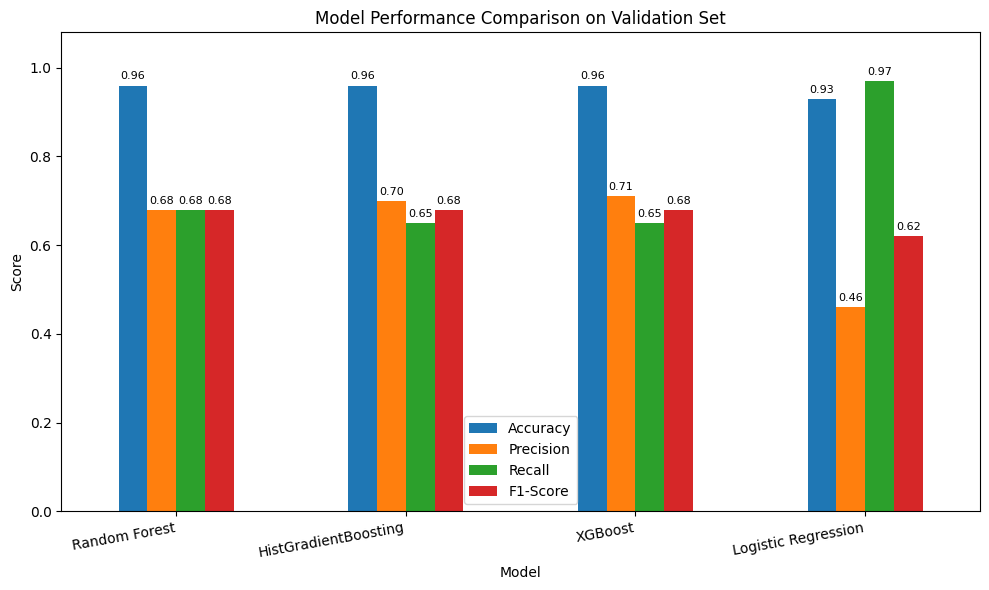

In [27]:
plot_metric_comparison(
    df=results_df, 
    dataset="Validation Set",
    save_path=f"{MODEL_PATH}/model_performance_comparison_plot.png"
)

## 8. Evaluation

### 8.1. Evaluation Results Save Directory

In [28]:
RESULTS_PATH = Path(f"{OUTPUT_DIR}/eval_results")
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

### 8.2. Loading Saved Models

In [29]:
loaded_models = {}

for model_path in MODEL_PATH.glob("*.joblib"):
    model_name = model_path.stem
    loaded_models[model_name] = joblib.load(model_path)
    
    print(f">> [INFO] Loaded {model_name}")

>> [INFO] Loaded histgradientboosting
>> [INFO] Loaded logistic_regression
>> [INFO] Loaded random_forest
>> [INFO] Loaded xgboost


### 8.3. Evaluation Loop

In [30]:
eval_results = []

for model_name, loaded_model in loaded_models.items():
    result = evaluate_model(
        model_name=model_name,
        model=loaded_model,
        X=X_test,
        y=y_test
    )

    eval_results.append(result)
    
loaded_results_df = pd.DataFrame(eval_results).round(2)

### 8.4. Validation Results Comparison

In [31]:
loaded_results_df = loaded_results_df.sort_values(by="F1-Score", ascending=False)
display(loaded_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,histgradientboosting,0.96,0.72,0.67,0.70
2,random_forest,0.96,0.69,0.71,0.70
3,xgboost,0.96,0.71,0.67,0.69
1,logistic_regression,0.93,0.46,0.97,0.62


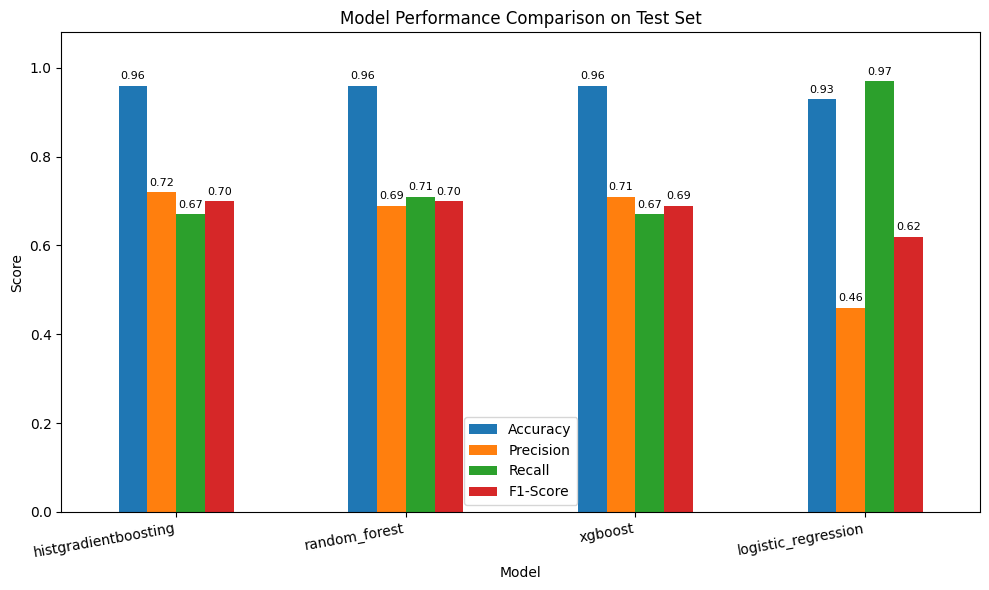

In [32]:
plot_metric_comparison(
    df=loaded_results_df,
    dataset="Test Set",
    save_path=f"{RESULTS_PATH}/test_model_performance_comparison.png"
)

### 8.5. Additional Evaluation Plots

## 9. End

In [33]:
elapsed_time = time.time() - start_time
print(f">> [INFO] Elapsed Time: {elapsed_time:.3f} seconds | {elapsed_time / 60:.3f} minutes")

>> [INFO] Elapsed Time: 33.428 seconds | 0.557 minutes
